In [28]:
import numpy             as     np
import matplotlib.pyplot as     plt
from matplotlib.ticker   import MaxNLocator
from scipy.stats         import norm, poisson

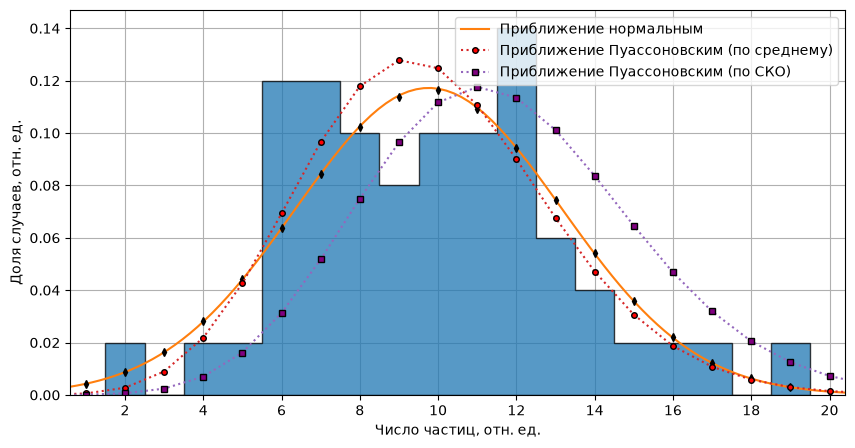

In [29]:
random_generator = np.random.default_rng(seed=67)

samples = random_generator.poisson(lam=10, size=50)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(samples, np.arange(min(samples), max(samples)+2) - 0.5, density=True,\
        facecolor="C0", alpha=0.75, edgecolor="black", histtype="stepfilled")

ax.set_xlabel('Число частиц, отн. ед.')
ax.set_ylabel('Доля случаев, отн. ед.')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
xmin, xmax = plt.xlim()
ax.autoscale(enable=False, axis="x")

space = np.linspace(np.floor(xmin), np.ceil(xmax), 5*(int(np.ceil(xmax) - np.floor(xmin)) + 1))
markers = np.linspace(np.floor(xmin), np.ceil(xmax) + 1, int(np.ceil(xmax) - np.floor(xmin)) + 2)

# Нормальное
ax.plot(space, norm.pdf(space, loc=np.mean(samples), scale=np.std(samples)), label="Приближение нормальным")
ax.plot(markers[:-1], np.diff(norm.cdf(markers-0.5, loc=np.mean(samples), scale=np.std(samples))), \
        marker="d", markerfacecolor='black', markeredgecolor='black', markersize=4,\
        linestyle="none")

# Пуассон
ax.plot(markers[:-1], poisson.pmf(markers[:-1], np.mean(samples)), label="Приближение Пуассоновским (по среднему)", \
        marker="o", markerfacecolor='red', markeredgecolor='black', markersize=4,\
        linestyle=":")

ax.plot(markers[:-1], poisson.pmf(markers[:-1], np.std(samples)**2), label="Приближение Пуассоновским (по СКО)", \
        marker="s", markerfacecolor='purple', markeredgecolor='black', markersize=4,\
        linestyle=":")

ax.legend()
ax.grid()
ax.set_axisbelow(True)
plt.savefig("1/my_graph4.png", bbox_inches="tight", dpi=300)

plt.show()

<Figure size 640x480 with 0 Axes>

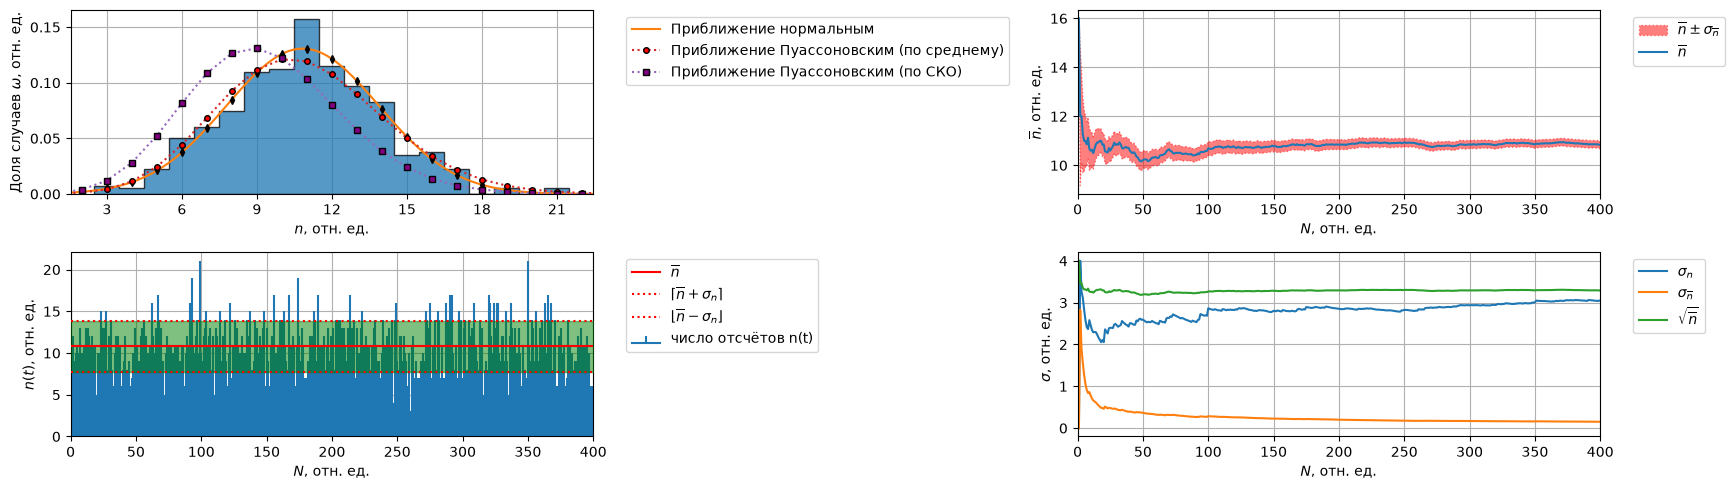

In [30]:
plt.clf()
fig, ax = plt.subplots(2, 2, figsize=(17.5, 5))
with open("1/эксперимент_2022-12-23_13-08-52.txt") as r:
    samples = np.array(r.readlines()[2:4002]).astype(int).reshape(-1, 10).sum(axis=1)
ax[1, 0].stem(samples, label="число отсчётов n(t)", markerfmt="", basefmt="")
ax[1, 0].axhline(np.mean(samples), color="red", label="$\overline{n}$", \
                zorder=5)
std_mn = np.std(samples)
ax[1, 0].fill_between(ax[1, 0].get_xlim(), [np.mean(samples) + std_mn]*2, [np.mean(samples) - std_mn]*2, \
                     color="green", alpha=0.5, zorder=4)
ax[1, 0].axhline(np.mean(samples) + std_mn, color="red", linestyle=":", \
                 label="$\\lceil\overline{n}+\sigma_{n}\\rceil$", \
                 zorder=5)
ax[1, 0].axhline(np.mean(samples) - std_mn, color="red", linestyle=":", \
                 label="$\\lfloor\overline{n}-\sigma_{n}\\rfloor$", \
                 zorder=5)
ax[1, 0].set_xlim(0, len(samples))
ax[1, 0].set_ylim(0, ax[1,0].get_ylim()[1])
ax[1, 0].grid()
ax[1, 0].set_axisbelow(True)
ax[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax[1, 0].set_xlabel('$N$, отн. ед.')
ax[1, 0].set_ylabel('$n(t)$, отн. ед.')
ax[0, 0].hist(samples, np.arange(min(samples), max(samples)+2) - 0.5, density=True,\
        facecolor="C0", alpha=0.75, edgecolor="black", histtype="stepfilled")

ax[0, 0].xaxis.set_major_locator(MaxNLocator(integer=True))
xmin, xmax = ax[0, 0].get_xlim()
ax[0, 0].autoscale(enable=False, axis="x")

space = np.linspace(np.floor(xmin), np.ceil(xmax), 5*(int(np.ceil(xmax) - np.floor(xmin)) + 1))
markers = np.linspace(np.floor(xmin), np.ceil(xmax) + 1, int(np.ceil(xmax) - np.floor(xmin)) + 2)

# Нормальное
ax[0, 0].plot(space, norm.pdf(space, loc=np.mean(samples), scale=np.std(samples)), label="Приближение нормальным")
ax[0, 0].plot(markers[:-1], np.diff(norm.cdf(markers-0.5, loc=np.mean(samples), scale=np.std(samples))), \
        marker="d", markerfacecolor='black', markeredgecolor='black', markersize=4,\
        linestyle="none")

# Пуассон
ax[0, 0].plot(markers[:-1], poisson.pmf(markers[:-1], np.mean(samples)), label="Приближение Пуассоновским (по среднему)", \
        marker="o", markerfacecolor='red', markeredgecolor='black', markersize=4,\
        linestyle=":")

ax[0, 0].plot(markers[:-1], poisson.pmf(markers[:-1], np.std(samples)**2), label="Приближение Пуассоновским (по СКО)", \
        marker="s", markerfacecolor='purple', markeredgecolor='black', markersize=4,\
        linestyle=":")
ax[0, 0].grid()
ax[0, 0].set_axisbelow(True)
ax[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax[0, 0].set_xlabel('$n$, отн. ед.')
ax[0, 0].set_ylabel('Доля случаев $\omega$, отн. ед.')


mean_n = np.array([np.mean(samples[0:n]) for n in range(1, len(samples)+1)])
std_mn  = np.array([np.std(samples[0:n])/np.sqrt(n) for n in range(1, len(samples)+1)])
ax[0, 1].fill_between(np.arange(1, len(samples)+1), mean_n + std_mn, mean_n - std_mn, linestyle=":", \
                     color="red", alpha=0.5, label="$\overline{n}\pm\sigma_{\overline{n}}$")
ax[0, 1].plot(np.arange(1, len(samples)+1), mean_n, label="$\overline{n}$")
ax[0, 1].set_xlim(0, len(samples))
ax[0, 1].set_xlabel('$N$, отн. ед.')
ax[0, 1].set_ylabel('$\overline{n}$, отн. ед.')
ax[0, 1].grid()
ax[0, 1].set_axisbelow(True)
ax[0, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

std_n = np.array([np.std(samples[0:n]) for n in range(1, len(samples)+1)])
ax[1, 1].plot(np.arange(1, len(samples)+1), std_n, label="$\sigma_n$")
ax[1, 1].plot(np.arange(1, len(samples)+1), std_mn, label="$\sigma_{\overline{n}}$")
ax[1, 1].plot(np.arange(1, len(samples)+1), np.sqrt(mean_n), label="$\sqrt{\overline{n}}$")
ax[1, 1].set_xlim(0, len(samples))
ax[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax[1, 1].grid()
ax[1, 1].set_axisbelow(True)
ax[1, 1].set_ylabel('$\sigma$, отн. ед.')
ax[1, 1].set_xlabel('$N$, отн. ед.')
plt.tight_layout()
for i, axes in enumerate(ax.flat):
  bbox = axes.get_tightbbox(fig.canvas.get_renderer())
  extent = bbox.transformed(fig.dpi_scale_trans.inverted())
  fig.savefig(f"1/subplot_{i+1}.png", bbox_inches=extent, dpi=300)
    
plt.savefig("1/4graph.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

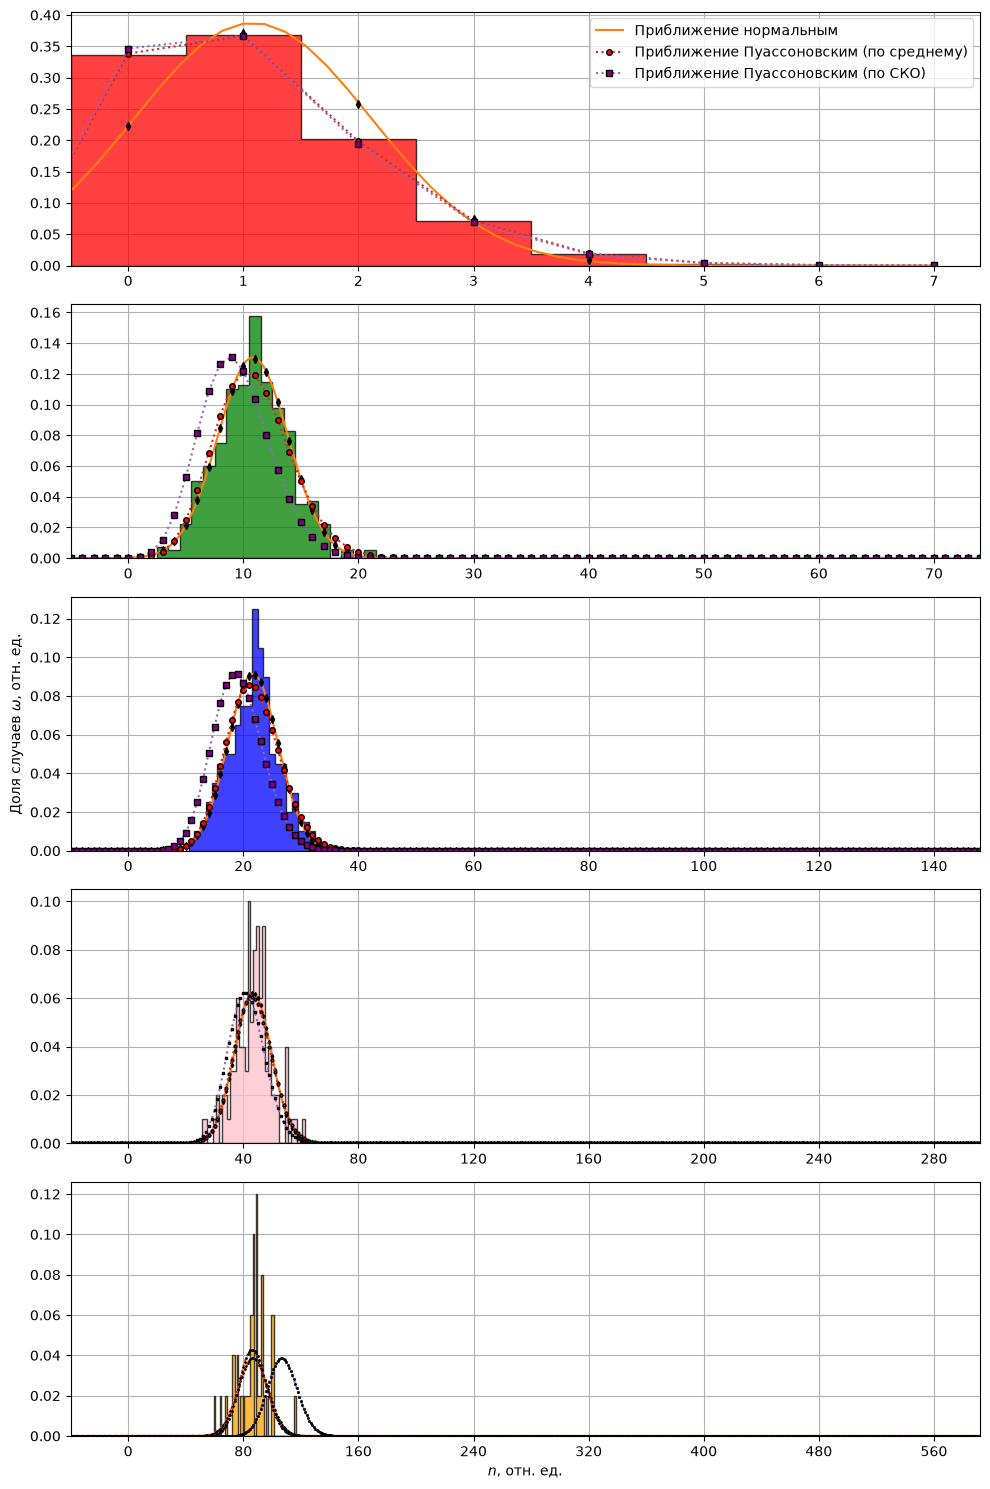

In [31]:
plt.clf()
fig, ax = plt.subplots(5, 1, figsize=(10, 15))
with open("1/эксперимент_2022-12-23_13-08-52.txt") as r:
    samples = np.array(r.readlines()[2:4002]).astype(int)

samples_1  = samples.reshape(-1, 1 ).sum(axis=1)

ax[0].hist(samples_1, np.arange(min(samples_1), max(samples_1)+2) - 0.5, density=True,\
        facecolor="red", alpha=0.75, edgecolor="black", histtype="stepfilled")
ax[0].xaxis.set_major_locator(MaxNLocator(integer=True))

xmin, xmax = ax[0].get_xlim()
space = np.linspace(np.floor(xmin), np.ceil(xmax), 5*(int(np.ceil(xmax) - np.floor(xmin)) + 1))
markers = np.linspace(np.floor(xmin), np.ceil(xmax) + 1, int(np.ceil(xmax) - np.floor(xmin)) + 2)
# Нормальное
ax[0].plot(space, norm.pdf(space, loc=np.mean(samples_1), scale=np.std(samples_1)), label="Приближение нормальным")
ax[0].plot(markers[:-1], np.diff(norm.cdf(markers-0.5, loc=np.mean(samples_1), scale=np.std(samples_1))), \
        marker="d", markerfacecolor='black', markeredgecolor='black', markersize=4,\
        linestyle="none")
# Пуассон
ax[0].plot(markers[:-1], poisson.pmf(markers[:-1], np.mean(samples_1)), label="Приближение Пуассоновским (по среднему)", \
        marker="o", markerfacecolor='red', markeredgecolor='black', markersize=4,\
        linestyle=":")

ax[0].plot(markers[:-1], poisson.pmf(markers[:-1], np.std(samples_1)**2), label="Приближение Пуассоновским (по СКО)", \
        marker="s", markerfacecolor='purple', markeredgecolor='black', markersize=4,\
        linestyle=":")
ax[0].set_xlim(-0.5, ax[0].get_xlim()[1])

ax[1].autoscale(enable=False, axis="x")
ax[1].set_xticks(ax[0].get_xticks()*10)
ax[1].set_xlim(np.array(ax[0].get_xlim())*10)
samples_10 = samples.reshape(-1, 10).sum(axis=1)
ax[1].hist(samples_10, np.arange(min(samples_10), max(samples_10)+2) - 0.5, density=True,\
        facecolor="green", alpha=0.75, edgecolor="black", histtype="stepfilled", label="$\\tau=10$")
xmin, xmax = ax[1].get_xlim()
space = np.linspace(np.floor(xmin), np.ceil(xmax), 5*(int(np.ceil(xmax) - np.floor(xmin)) + 1))
markers = np.linspace(np.floor(xmin), np.ceil(xmax) + 1, int(np.ceil(xmax) - np.floor(xmin)) + 2)
# Нормальное
ax[1].plot(space, norm.pdf(space, loc=np.mean(samples_10), scale=np.std(samples_10)), label="Приближение нормальным")
ax[1].plot(markers[:-1], np.diff(norm.cdf(markers-0.5, loc=np.mean(samples_10), scale=np.std(samples_10))), \
        marker="d", markerfacecolor='black', markeredgecolor='black', markersize=4,\
        linestyle="none")
# Пуассон
ax[1].plot(markers[:-1], poisson.pmf(markers[:-1], np.mean(samples_10)), label="Приближение Пуассоновским (по среднему)", \
        marker="o", markerfacecolor='red', markeredgecolor='black', markersize=4,\
        linestyle=":")

ax[1].plot(markers[:-1], poisson.pmf(markers[:-1], np.std(samples_10)**2), label="Приближение Пуассоновским (по СКО)", \
        marker="s", markerfacecolor='purple', markeredgecolor='black', markersize=4,\
        linestyle=":")

ax[2].autoscale(enable=False, axis="x")
ax[2].set_xticks(ax[0].get_xticks()*20)
ax[2].set_xlim(np.array(ax[0].get_xlim())*20)
samples_20 = samples.reshape(-1, 20).sum(axis=1)
ax[2].hist(samples_20, np.arange(min(samples_20), max(samples_20)+2) - 0.5, density=True,\
        facecolor="blue", alpha=0.75, edgecolor="black", histtype="stepfilled", label="$\\tau=20$")
xmin, xmax = ax[2].get_xlim()
space = np.linspace(np.floor(xmin), np.ceil(xmax), 5*(int(np.ceil(xmax) - np.floor(xmin)) + 1))
markers = np.linspace(np.floor(xmin), np.ceil(xmax) + 1, int(np.ceil(xmax) - np.floor(xmin)) + 2)
# Нормальное
ax[2].plot(space, norm.pdf(space, loc=np.mean(samples_20), scale=np.std(samples_20)), label="Приближение нормальным")
ax[2].plot(markers[:-1], np.diff(norm.cdf(markers-0.5, loc=np.mean(samples_20), scale=np.std(samples_20))), \
        marker="d", markerfacecolor='black', markeredgecolor='black', markersize=4,\
        linestyle="none")
# Пуассон
ax[2].plot(markers[:-1], poisson.pmf(markers[:-1], np.mean(samples_20)), label="Приближение Пуассоновским (по среднему)", \
        marker="o", markerfacecolor='red', markeredgecolor='black', markersize=4,\
        linestyle=":")

ax[2].plot(markers[:-1], poisson.pmf(markers[:-1], np.std(samples_20)**2), label="Приближение Пуассоновским (по СКО)", \
        marker="s", markerfacecolor='purple', markeredgecolor='black', markersize=4,\
        linestyle=":")

ax[3].autoscale(enable=False, axis="x")
ax[3].set_xticks(ax[0].get_xticks()*40)
ax[3].set_xlim(np.array(ax[0].get_xlim())*40)
samples_40 = samples.reshape(-1, 40).sum(axis=1)
ax[3].hist(samples_40, np.arange(min(samples_40), max(samples_40)+2) - 0.5, density=True,\
        facecolor="pink", alpha=0.75, edgecolor="black", histtype="stepfilled", label="$\\tau=40$")
xmin, xmax = ax[3].get_xlim()
space = np.linspace(np.floor(xmin), np.ceil(xmax), 5*(int(np.ceil(xmax) - np.floor(xmin)) + 1))
markers = np.linspace(np.floor(xmin), np.ceil(xmax) + 1, int(np.ceil(xmax) - np.floor(xmin)) + 2)
# Нормальное
ax[3].plot(space, norm.pdf(space, loc=np.mean(samples_40), scale=np.std(samples_40)), label="Приближение нормальным")
ax[3].plot(markers[:-1], np.diff(norm.cdf(markers-0.5, loc=np.mean(samples_40), scale=np.std(samples_40))), \
        marker="d", markerfacecolor='black', markeredgecolor='black', markersize=2,\
        linestyle="none")
# Пуассон
ax[3].plot(markers[:-1], poisson.pmf(markers[:-1], np.mean(samples_40)), label="Приближение Пуассоновским (по среднему)", \
        marker="o", markerfacecolor='red', markeredgecolor='black', markersize=2,\
        linestyle=":")

ax[3].plot(markers[:-1], poisson.pmf(markers[:-1], np.std(samples_40)**2), label="Приближение Пуассоновским (по СКО)", \
        marker="s", markerfacecolor='purple', markeredgecolor='black', markersize=2,\
        linestyle=":")

ax[4].autoscale(enable=False, axis="x")
ax[4].set_xticks(ax[0].get_xticks()*80)
ax[4].set_xlim(np.array(ax[0].get_xlim())*80)
samples_80 = samples.reshape(-1, 80).sum(axis=1)
ax[4].hist(samples_80, np.arange(min(samples_80), max(samples_80)+2) - 0.5, density=True,\
        facecolor="orange", alpha=0.75, edgecolor="black", histtype="stepfilled", label="$\\tau=80$")
xmin, xmax = ax[4].get_xlim()
space = np.linspace(np.floor(xmin), np.ceil(xmax), 5*(int(np.ceil(xmax) - np.floor(xmin)) + 1))
markers = np.linspace(np.floor(xmin), np.ceil(xmax) + 1, int(np.ceil(xmax) - np.floor(xmin)) + 2)
# Нормальное
ax[4].plot(space, norm.pdf(space, loc=np.mean(samples_80), scale=np.std(samples_80)), label="Приближение нормальным")
ax[4].plot(markers[:-1], np.diff(norm.cdf(markers-0.5, loc=np.mean(samples_80), scale=np.std(samples_80))), \
        marker="d", markerfacecolor='black', markeredgecolor='black', markersize=1,\
        linestyle="none")
# Пуассон
ax[4].plot(markers[:-1], poisson.pmf(markers[:-1], np.mean(samples_80)), label="Приближение Пуассоновским (по среднему)", \
        marker="o", markerfacecolor='red', markeredgecolor='black', markersize=1,\
        linestyle=":")

ax[4].plot(markers[:-1], poisson.pmf(markers[:-1], np.std(samples_80)**2), label="Приближение Пуассоновским (по СКО)", \
        marker="s", markerfacecolor='purple', markeredgecolor='black', markersize=1,\
        linestyle=":")
for i in range(5):
    ax[i].grid()
    ax[i].set_axisbelow(True)
ax[2].set_ylabel("Доля случаев $\omega$, отн. ед.")
ax[4].set_xlabel("$n$, отн. ед.")
ax[0].legend()
plt.tight_layout()
plt.savefig("1/my_graph5.png", bbox_inches="tight", dpi=300)

In [32]:
print([[samples_10[i+10*j] for i in range(10)] for j in range(len(samples_10)/10)])

TypeError: 'float' object cannot be interpreted as an integer

In [ ]:
s = samples_80
for j in range(len(s)//10):
    print("$" + str(10*j), *[s[i+10*j] for i in range(10)], sep="$ & $", end="$\\\\\n")

In [33]:
s=samples_10
np.std(s)/len(s)

np.float64(0.007631941000656386)

In [34]:
samples_10

array([16,  8, 12,  9, 10, 11, 10, 13,  7, 10, 11,  9, 13, 13, 12, 11, 12,
       11,  8, 11,  5, 10, 10, 15,  8, 13, 13, 15,  8, 12, 10, 14,  8,  6,
       10, 12, 12,  9, 11,  6,  8,  9, 12,  8,  5,  9,  6,  7, 10, 13, 11,
       11,  9,  7, 12, 13, 14, 10, 12, 10,  8, 11, 16, 12, 10, 13, 12, 17,
       14, 13,  6,  9,  5, 10, 12, 11, 10, 11, 10,  7, 11, 11, 11,  9,  9,
       11, 11,  6, 10, 12, 11, 16,  7, 19, 11, 10, 12, 14, 10, 21, 10,  9,
       12, 13, 15, 11, 12, 13,  8, 12,  5, 13, 12, 11, 15,  9,  7, 12, 14,
        9,  6, 10, 16,  7, 11,  7, 14, 13, 11, 10, 10, 12,  8, 10, 10, 14,
       12, 15,  7,  8,  9, 14, 11, 13, 10, 12, 11, 13, 15,  6, 13,  9,  6,
       11, 12, 10, 17, 10, 10, 11, 14, 12, 14, 15, 11,  9,  8, 17,  5, 11,
       12, 11,  6, 11, 19, 12,  9, 13, 11,  7,  7,  6,  9, 12, 10, 12, 15,
       14,  9, 17,  9, 11, 11, 11, 12,  8, 11, 13,  9, 12,  9, 13,  8, 14,
        6, 14, 14, 12, 13, 13, 11,  9, 13, 12, 17, 13,  9, 14,  7, 13,  6,
       10, 13, 15, 11, 11

In [35]:
s = samples_80
a, b = np.histogram(s, np.arange(min(s), max(s)+2), density=True)
for omega, n in zip(a, b[:-1]):
    print(f"{n} & ${omega}$\\\\")

60 & $0.02$\\
61 & $0.0$\\
62 & $0.0$\\
63 & $0.0$\\
64 & $0.02$\\
65 & $0.0$\\
66 & $0.0$\\
67 & $0.0$\\
68 & $0.02$\\
69 & $0.0$\\
70 & $0.0$\\
71 & $0.0$\\
72 & $0.0$\\
73 & $0.04$\\
74 & $0.04$\\
75 & $0.02$\\
76 & $0.04$\\
77 & $0.0$\\
78 & $0.02$\\
79 & $0.02$\\
80 & $0.0$\\
81 & $0.02$\\
82 & $0.02$\\
83 & $0.02$\\
84 & $0.02$\\
85 & $0.06$\\
86 & $0.06$\\
87 & $0.1$\\
88 & $0.0$\\
89 & $0.12$\\
90 & $0.02$\\
91 & $0.02$\\
92 & $0.02$\\
93 & $0.08$\\
94 & $0.02$\\
95 & $0.0$\\
96 & $0.02$\\
97 & $0.02$\\
98 & $0.0$\\
99 & $0.0$\\
100 & $0.06$\\
101 & $0.06$\\
102 & $0.0$\\
103 & $0.0$\\
104 & $0.0$\\
105 & $0.0$\\
106 & $0.0$\\
107 & $0.0$\\
108 & $0.0$\\
109 & $0.0$\\
110 & $0.0$\\
111 & $0.0$\\
112 & $0.0$\\
113 & $0.0$\\
114 & $0.0$\\
115 & $0.0$\\
116 & $0.02$\\


In [36]:
s = samples_80
n = np.arange(min(s), max(s)+2)
mean = np.mean(s)
sigma = np.std(s)
sigma1 = 0
sigma2 = 0
sigma3 = 0
for i in s:
    if mean - sigma <= i <= mean + sigma:
        sigma1 += 1
    if mean - 2*sigma <= i <= mean + 2*sigma:
        sigma2 += 1
    if mean - 3*sigma <= i <= mean + 3*sigma:
        sigma3 += 1
print(
    "\\(\\pm\\sigma_{{10}}=\\pm{:.1f}\\) & ${}$ & ${:.3f}$ & $0.683$ \\\\\n"
    "\\(\\pm 2\\sigma_{{10}}=\\pm{:.1f}\\) & ${}$ & ${:.3f}$ & $0.954$ \\\\\n"
    "\\(\\pm 3\\sigma_{{10}}=\\pm{:.1f}\\) & ${}$ & ${:.3f}$ & $0.997$ \\\\".format(
        sigma, sigma1, sigma1/len(s), 
        2*sigma, sigma2, sigma2/len(s), 
        3*sigma, sigma3, sigma3/len(s)
    )
)

\(\pm\sigma_{10}=\pm10.4\) & $33$ & $0.660$ & $0.683$ \\
\(\pm 2\sigma_{10}=\pm20.7\) & $47$ & $0.940$ & $0.954$ \\
\(\pm 3\sigma_{10}=\pm31.1\) & $50$ & $1.000$ & $0.997$ \\


In [37]:
s=samples_80
N=4000
print(np.mean(s), np.std(s), np.std(s)/np.sqrt(len(s)), np.mean(s)/(N/len(s)), (np.std(s)*np.sqrt(len(s)))/N, np.sqrt(np.mean(s)))

86.66 10.352989906302431 1.4641338736604657 1.08325 0.018301673420755823 9.309135298189624


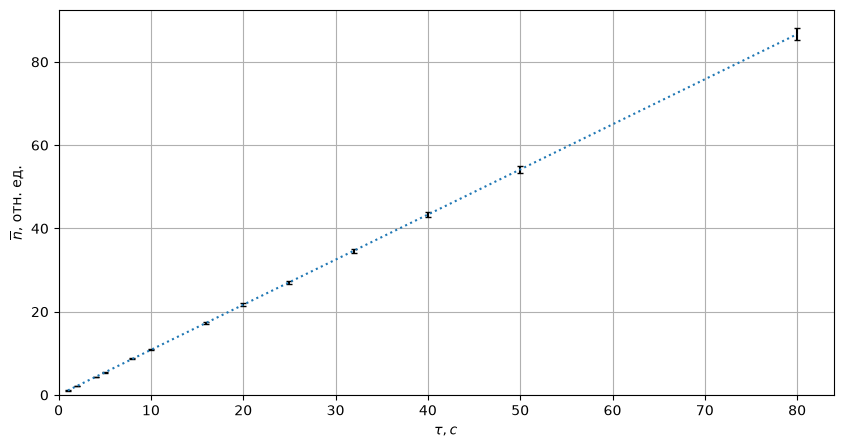

In [38]:
taus = np.array([1, 2, 4, 5, 8, 10, 16, 20, 25, 32, 40, 50, 80])
ns = 4000 / taus                       # number of summed samples for each τ

with open("1/эксперимент_2022-12-23_13-08-52.txt") as r:
    samples = np.array(r.readlines()[2:4002]).astype(int)

samples_tau = [samples.reshape(-1, i).sum(axis=1) for i in taus]

means = np.array([s.mean() for s in samples_tau])
stds  = np.array([s.std()  for s in samples_tau])

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(taus, means, stds / np.sqrt(ns), linestyle=":", \
           ecolor='black', capsize=2)
ax.set_xlim(0, ax.get_xlim()[1])
ax.set_ylim(0, ax.get_ylim()[1])
ax.set_xlabel('$\\tau, c$')
ax.set_ylabel('$\overline{n}$, отн. ед.')
ax.grid()
ax.set_axisbelow(True)
plt.savefig("1/avg(tau).png", bbox_inches="tight", dpi=300)

<Figure size 640x480 with 0 Axes>

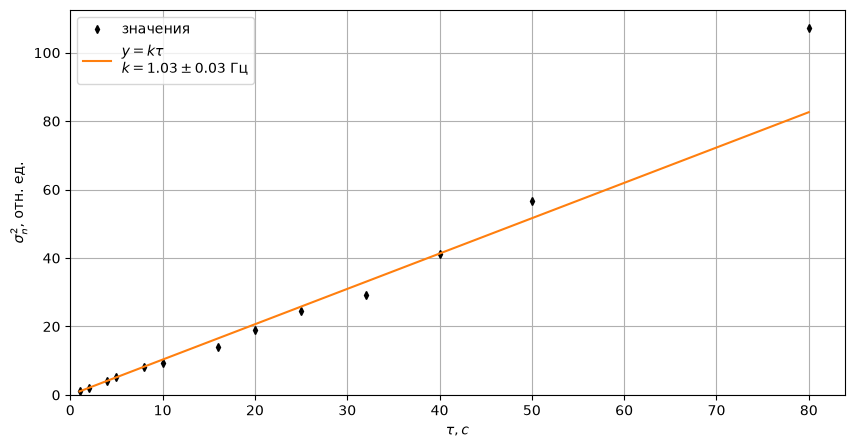

In [39]:
plt.clf()
fig, ax = plt.subplots(figsize=(10, 5))
k = np.linalg.lstsq(taus[:-1, np.newaxis], (stds**2)[:-1])
sigma_k = np.sqrt((1/(len(taus)-2) * (np.mean((stds**4)[:-1])/np.mean(taus[:-1]**2) - k[0][0]**2)))
ax.plot(taus, stds**2,\
        marker="d", markerfacecolor='black', markeredgecolor='black', markersize=4,\
        linestyle="none", label="значения")
ax.plot(taus, k[0][0]*taus, label=f"$y=k\\tau$\n$k={k[0][0]:.2f}\pm{sigma_k:.2f}$ Гц")
ax.set_xlim(0, ax.get_xlim()[1])
ax.set_ylim(0, ax.get_ylim()[1])
ax.set_xlabel('$\\tau, c$')
ax.set_ylabel('$\sigma_n^2$, отн. ед.')
ax.grid()
ax.set_axisbelow(True)
ax.legend()
plt.savefig("1/sigma(tau).png", bbox_inches="tight", dpi=300)

<Figure size 640x480 with 0 Axes>

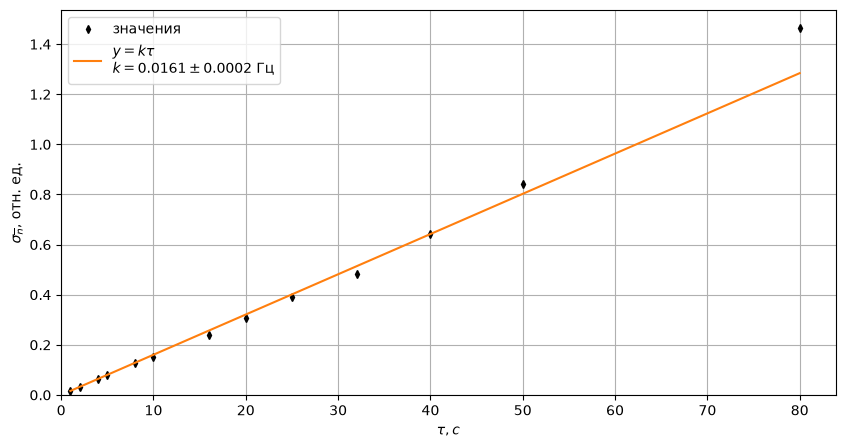

In [40]:
plt.clf()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(taus, stds / np.sqrt(ns),\
        marker="d", markerfacecolor='black', markeredgecolor='black', markersize=4,\
        linestyle="none", label="значения")
k = np.linalg.lstsq(taus[:-1, np.newaxis], (stds / np.sqrt(ns))[:-1])[0][0]
sigma_k = np.sqrt((1/(len(taus)-2) * (np.mean((stds / np.sqrt(ns))[:-1]**2)/np.mean(taus[:-1]**2) - k**2)))
ax.plot(taus, k*taus, label=f"$y=k\\tau$\n$k={k:.4f}\pm{sigma_k:.4f}$ Гц")
ax.set_xlim(0, ax.get_xlim()[1])
ax.set_ylim(0, ax.get_ylim()[1])
ax.set_xlabel('$\\tau, c$')
ax.set_ylabel('$\sigma_{\overline{n}}$, отн. ед.')
ax.grid()

ax.legend()
plt.savefig("1/avgsigma(tau).png", bbox_inches="tight", dpi=300)

<Figure size 640x480 with 0 Axes>

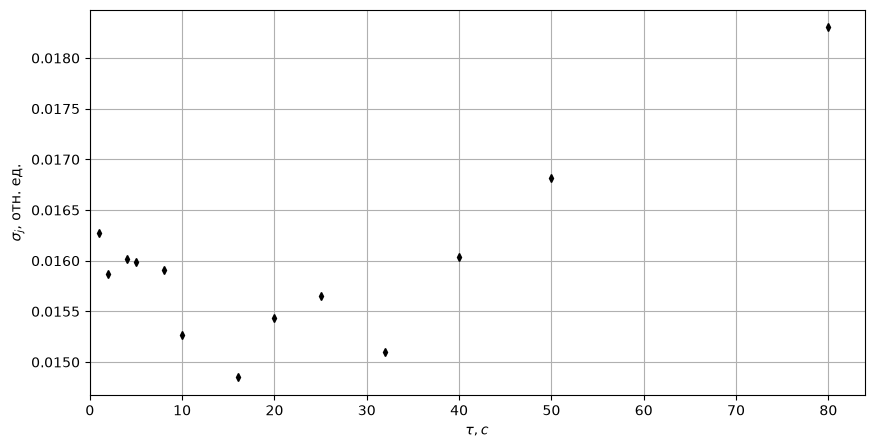

In [41]:
plt.clf()
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(taus, (stds / np.sqrt(ns))/taus,\
        marker="d", markerfacecolor='black', markeredgecolor='black', markersize=4,\
        linestyle="none")
ax.set_xlim(0, ax.get_xlim()[1])
ax.set_xlabel('$\\tau, c$')
ax.set_ylabel('$\sigma_{j}$, отн. ед.')
ax.grid()
ax.set_axisbelow(True)
plt.savefig("1/jsigma(tau).png", bbox_inches="tight", dpi=300)

<Figure size 640x480 with 0 Axes>

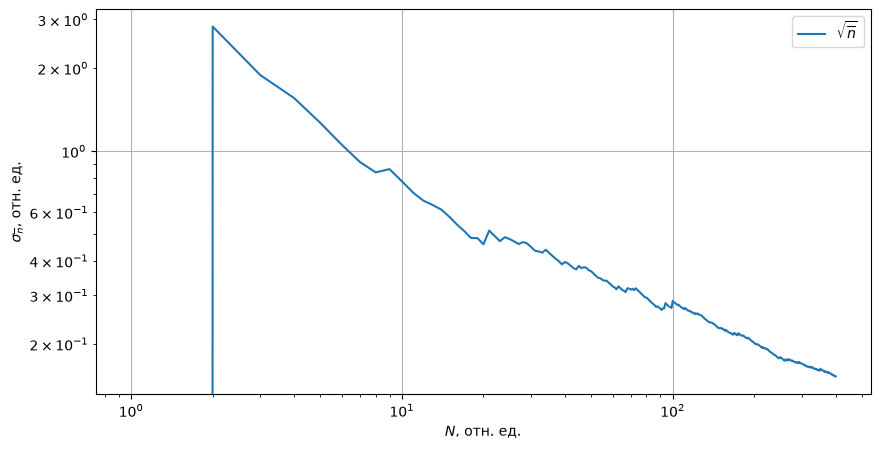

In [42]:
plt.clf()
samples_k = samples_tau[5]
fig, ax = plt.subplots(figsize=(10, 5))
mean_n = np.array([np.mean(samples_k[0:n]) for n in range(1, len(samples_k)+1)])
std_mn  = np.array([np.std(samples_k[0:n])/np.sqrt(n) for n in range(1, len(samples_k)+1)])

std_n = np.array([np.std(samples_k[0:n]) for n in range(1, len(samples_k)+1)])
ax.loglog(np.arange(1, len(samples_k)+1), std_mn, label="$\sqrt{\overline{n}}$")
ax.set_xlabel('$N$, отн. ед.')
ax.set_ylabel('$\sigma_{\overline{n}}$, отн. ед.')
ax.legend()
ax.grid()
ax.set_axisbelow(True)
plt.savefig("1/loglogsigma(N).png", bbox_inches="tight", dpi=300)

In [43]:
import numpy             as     np
import matplotlib.pyplot as     plt
from matplotlib.ticker   import MaxNLocator
from scipy.stats         import norm, poisson
from matplotlib.animation import FuncAnimation
from IPython import display

In [ ]:
with open("1/симуляция_2022-12-23_13-17-20.txt") as f:
    samples_all = np.array(f.readlines()[3:4003]).astype(int)
samples_all = samples_all.reshape(-1, 10).sum(axis=1)
fig, ax = plt.subplots(figsize=(10, 5))
xmin_g = 0
xmax_g = 0
def anim(n):
    global xmin_g, xmax_g
    print(n)
    plt.cla()
    if n <= 1:
        return
    samples = samples_all[:n]
    ax.hist(samples, np.arange(min(samples), max(samples)+2) - 0.5, density=True,\
            facecolor="C0", alpha=0.75, edgecolor="black", histtype="stepfilled")
    
    xmin, xmax = ax.get_xlim()
    ax.autoscale(enable=False, axis="x")
    if n==400:
        ax.set_xlabel('Число частиц, отн. ед.')
        ax.set_ylabel('Доля случаев, отн. ед.')
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        xmin_g, xmax_g = ax.get_xlim()
    xmin, xmax = xmin_g, xmax_g
    
    space = np.linspace(np.floor(xmin), np.ceil(xmax), 5*(int(np.ceil(xmax) - np.floor(xmin)) + 1))
    markers = np.linspace(np.floor(xmin), np.ceil(xmax) + 1, int(np.ceil(xmax) - np.floor(xmin)) + 2)
    
    # Нормальное
    ax.plot(space, norm.pdf(space, loc=np.mean(samples), scale=np.std(samples)), label="Приближение нормальным")
    ax.plot(markers[:-1], np.diff(norm.cdf(markers-0.5, loc=np.mean(samples), scale=np.std(samples))), \
            marker="d", markerfacecolor='black', markeredgecolor='black', markersize=4,\
            linestyle="none")
    
    # Пуассон
    ax.plot(markers[:-1], poisson.pmf(markers[:-1], np.mean(samples)), label="Приближение Пуассоновским (по среднему)", \
            marker="o", markerfacecolor='red', markeredgecolor='black', markersize=4,\
            linestyle=":")
    
    ax.plot(markers[:-1], poisson.pmf(markers[:-1], np.std(samples)**2), label="Приближение Пуассоновским (по СКО)", \
            marker="s", markerfacecolor='purple', markeredgecolor='black', markersize=4,\
            linestyle=":")
    ax.set_xlim(xmin_g, xmax_g)
    

anim(400)
ax.autoscale(enable=False, axis="y")
ax.legend()
ax.grid()
ax.set_axisbelow(True)

animation = FuncAnimation(fig, anim, 400, interval=25)
#plt.show()
video = animation.to_html5_video()
html = display.HTML(video)
display.display(html) 

400
0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
